# Стадия 1: Генерация кандидатов

Сравниваем три подхода:
1. **PopularityRecommender** - бейзлайн, топ-N популярных
2. **SVDRecommender** - матричная факторизация (sklearn)
3. **ItemKNNRecommender** - item-based коллаборативная фильтрация

Цель этой стадии - recall: нужно, чтобы релевантные фильмы попали в кандидаты. Ранжировать их точно будет CatBoost на стадии 2.

In [1]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import time

from candidates import PopularityRecommender, SVDRecommender, ItemKNNRecommender
from metrics import evaluate_all, recall_at_k, coverage, ndcg_at_k


sns.set_theme(style='whitegrid', palette='muted')
DATA_DIR = Path('../data')
MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(exist_ok=True)

In [2]:
train_df = pd.read_parquet(DATA_DIR / 'train.parquet')
val_df   = pd.read_parquet(DATA_DIR / 'val.parquet')
movies   = pd.read_parquet(DATA_DIR / 'movies.parquet')
ratings  = pd.read_parquet(DATA_DIR / 'ratings.parquet')

# ground truth: последняя оценка каждого пользователя (val)
# Считаем релевантным фильм, который пользователь реально посмотрел
ground_truth = val_df[['user_id', 'movie_id']].copy()

# Оцениваем только на пользователях из train (нет cold start)
train_users = train_df['user_id'].unique()
ground_truth = ground_truth[ground_truth['user_id'].isin(train_users)]
eval_users   = ground_truth['user_id'].unique().tolist()

print(f'Train:       {len(train_df):,} оценок')
print(f'Val:         {len(val_df):,} оценок')
print(f'Eval users:  {len(eval_users):,}')
all_items = movies['movie_id'].values

Train:       976,049 оценок
Val:         18,120 оценок
Eval users:  6,040


## 1. Popularity Baseline

In [12]:
t0 = time.time()
pop = PopularityRecommender(top_k=100, min_ratings=50)
pop.fit(train_df)
recs_pop = pop.recommend(eval_users, top_k=100)
print(f'Время: {time.time()-t0:.1f}с')

metrics_pop = evaluate_all(recs_pop, ground_truth, k_values=[10, 20, 50, 100])
cov_pop = coverage(recs_pop, all_items, k=100)
print('\nPopularity Metrics:')
print(metrics_pop)
print(f'\nCoverage@100: {cov_pop:.3f}')

pop.save(MODELS_DIR / 'popularity.pkl')

Время: 13.7с

Popularity Metrics:
              @10     @20     @50    @100
Precision  0.0063  0.0054  0.0050  0.0039
Recall     0.0209  0.0360  0.0827  0.1292
NDCG       0.0140  0.0194  0.0324  0.0429
HitRate    0.0553  0.0934  0.1869  0.2715
MRR        0.0188  0.0215  0.0245  0.0257

Coverage@100: 0.146


## 2. SVD (Матричная факторизация)

n_components= 10 -> Recall@100=0.2215
n_components= 20 -> Recall@100=0.2238
n_components= 50 -> Recall@100=0.2089
n_components=100 -> Recall@100=0.1902
n_components=150 -> Recall@100=0.1732

Лучший результат: n_components=20 -> Recall@100=0.2238
Время: 19.9с

SVD Metrics:
              @10     @20     @50    @100
Precision  0.0163  0.0134  0.0094  0.0067
Recall     0.0545  0.0895  0.1563  0.2238
NDCG       0.0392  0.0516  0.0701  0.0855
HitRate    0.1406  0.2187  0.3483  0.4579
MRR        0.0550  0.0603  0.0644  0.0660

Coverage@100: 0.504


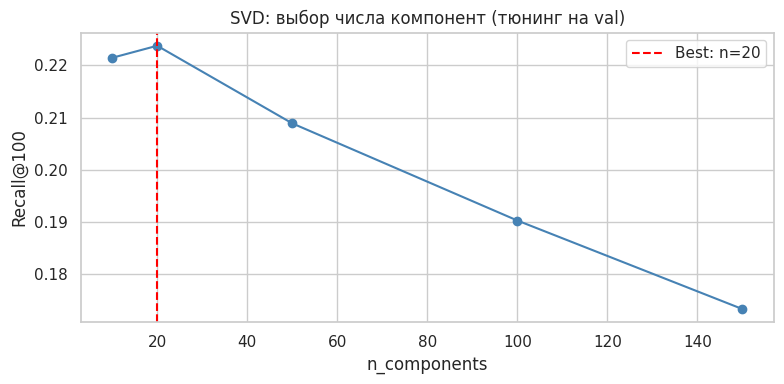

In [4]:
components_to_try = [10, 20, 50, 100, 150]
results_svd = []

t0 = time.time()
for n in components_to_try:
    m = SVDRecommender(top_k=100, n_components=n)
    m.fit(train_df)
    recs = m.recommend(eval_users, top_k=100)
    recall_val = recall_at_k(recs, ground_truth, k=100)
    results_svd.append({'n_components': n, 'recall': recall_val, 'model': m, 'recs': recs})
    print(f'n_components={n:3d} -> Recall@100={recall_val:.4f}')

best_svd = max(results_svd, key=lambda x: x['recall'])
print(f'\nЛучший результат: n_components={best_svd["n_components"]} -> Recall@100={best_svd["recall"]:.4f}')
print(f'Время: {time.time()-t0:.1f}с')

svd      = best_svd['model']
recs_svd = best_svd['recs']

metrics_svd = evaluate_all(recs_svd, ground_truth, k_values=[10, 20, 50, 100])
cov_svd     = coverage(recs_svd, all_items, k=100)
print('\nSVD Metrics:')
print(metrics_svd)
print(f'\nCoverage@100: {cov_svd:.3f}')

plt.figure(figsize=(8, 4))
plt.plot(
    [r['n_components'] for r in results_svd],
    [r['recall']       for r in results_svd],
    marker='o', color='steelblue'
)
plt.axvline(best_svd['n_components'], color='red', linestyle='--',
            label=f'Best: n={best_svd["n_components"]}')
plt.xlabel('n_components')
plt.ylabel('Recall@100')
plt.title('SVD: выбор числа компонент (тюнинг на val)')
plt.legend()
plt.tight_layout()
plt.show()

svd.save(MODELS_DIR / 'svd.pkl')

## 3. Item-KNN

In [5]:
t0 = time.time()
knn = ItemKNNRecommender(top_k=100, n_neighbors=20)
knn.fit(train_df)
recs_knn = knn.recommend(eval_users, top_k=100)
print(f'Время: {time.time()-t0:.1f}с')

metrics_knn = evaluate_all(recs_knn, ground_truth, k_values=[10, 20, 50, 100])
cov_knn     = coverage(recs_knn, all_items, k=100)
print('\nItemKNN Metrics:')
print(metrics_knn)
print(f'\nCoverage@100: {cov_knn:.3f}')

knn.save(MODELS_DIR / 'item_knn.pkl')

Время: 45.4с

ItemKNN Metrics:
              @10     @20     @50    @100
Precision  0.0000  0.0000  0.0001  0.0003
Recall     0.0001  0.0002  0.0017  0.0107
NDCG       0.0000  0.0001  0.0005  0.0025
HitRate    0.0003  0.0005  0.0041  0.0276
MRR        0.0000  0.0000  0.0001  0.0004

Coverage@100: 0.782


## 4. Сравнение моделей

In [6]:
comparison = pd.DataFrame({
    'Model':      ['Popularity', 'SVD', 'ItemKNN'],
    'Recall@10':  [recall_at_k(recs_pop, ground_truth, 10),
                   recall_at_k(recs_svd, ground_truth, 10),
                   recall_at_k(recs_knn, ground_truth, 10)],
    'Recall@50':  [recall_at_k(recs_pop, ground_truth, 50),
                   recall_at_k(recs_svd, ground_truth, 50),
                   recall_at_k(recs_knn, ground_truth, 50)],
    'Recall@100': [recall_at_k(recs_pop, ground_truth, 100),
                   recall_at_k(recs_svd, ground_truth, 100),
                   recall_at_k(recs_knn, ground_truth, 100)],
    'NDCG@10':    [ndcg_at_k(recs_pop, ground_truth, 10),
                   ndcg_at_k(recs_svd, ground_truth, 10),
                   ndcg_at_k(recs_knn, ground_truth, 10)],
    'Coverage@100': [cov_pop, cov_svd, cov_knn],
})

print(comparison.set_index('Model').to_string())

            Recall@10  Recall@50  Recall@100   NDCG@10  Coverage@100
Model                                                               
Popularity   0.020861   0.082726    0.129194  0.014016      0.145764
SVD          0.054470   0.156291    0.223786  0.039226      0.504249
ItemKNN      0.000110   0.001711    0.010706  0.000045      0.782127


Popularity: средний результат. Recall@100 = 0.129, Coverage = 0.146. Рекомендует одно и то же всем, поэтому coverage низкий. Работает за счёт того, что популярные фильмы действительно смотрят чаще.

SVD: лучший по всем метрикам качества. Recall@100 = 0.224, NDCG@10 = 0.039, Coverage = 0.504. Персонализация работает, каталог используется наполовину.

ItemKNN: очень плохие результаты. Recall@100 = 0.011, NDCG@10 = 0.000045, зато Coverage = 0.782. Модель находит много разных фильмов, но почти никогда не угадывает нужный. Причина плохого результата в разреженной матрице.

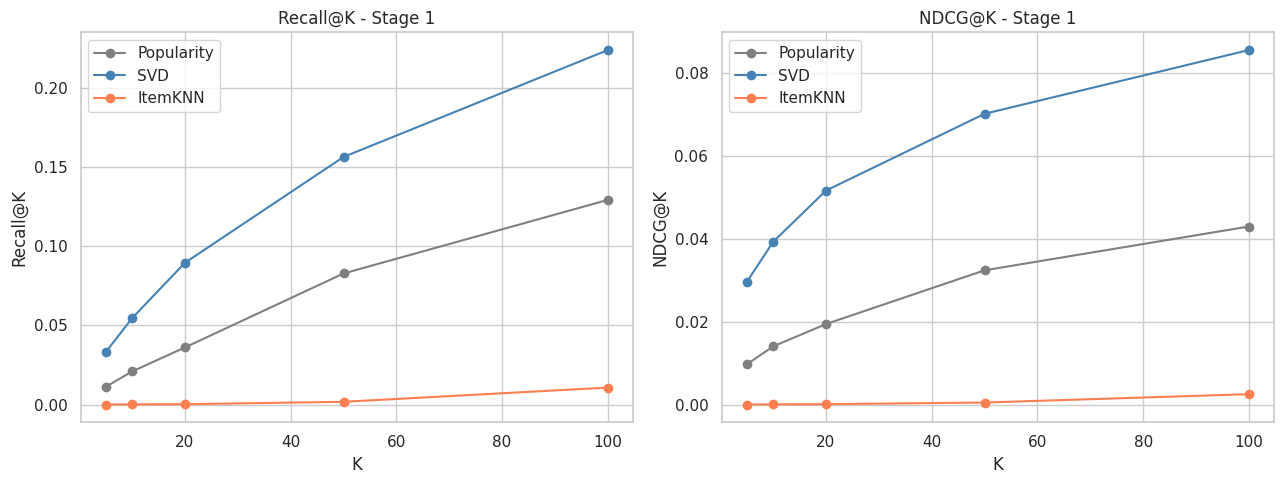

In [7]:
# График: Recall@K для трёх моделей
k_values = [5, 10, 20, 50, 100]
models_recs = {'Popularity': recs_pop, 'SVD': recs_svd, 'ItemKNN': recs_knn}
colors = {'Popularity': 'gray', 'SVD': 'steelblue', 'ItemKNN': 'coral'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for name, recs in models_recs.items():
    recalls = [recall_at_k(recs, ground_truth, k) for k in k_values]
    ndcgs   = [ndcg_at_k(recs, ground_truth, k)   for k in k_values]
    ax1.plot(k_values, recalls, marker='o', label=name, color=colors[name])
    ax2.plot(k_values, ndcgs,   marker='o', label=name, color=colors[name])

ax1.set_xlabel('K')
ax1.set_ylabel('Recall@K')
ax1.set_title('Recall@K - Stage 1')
ax1.legend()

ax2.set_xlabel('K')
ax2.set_ylabel('NDCG@K')
ax2.set_title('NDCG@K - Stage 1')
ax2.legend()

plt.tight_layout()
plt.savefig(DATA_DIR / 'candidates_comparison.png', bbox_inches='tight')
plt.show()

## 5. Сохранение кандидатов для стадии 2

Берём SVD как основной генератор.

In [11]:
best_candidates = recs_svd.copy()
best_candidates.columns = ['user_id', 'movie_id', 'candidate_score', 'candidate_rank']

# Добавляем флаг: входит ли фильм в топ-100 по популярности
pop_top = pop._popular_items.head(100)['movie_id'].values
best_candidates['in_popularity_top'] = best_candidates['movie_id'].isin(pop_top).astype(int)

# Все фильмы из val, факт просмотра = позитив
gt_set = set(zip(val_df['user_id'], val_df['movie_id']))

best_candidates['label'] = best_candidates.apply(
    lambda row: int((row['user_id'], row['movie_id']) in gt_set), axis=1
)

print(f'Кандидатов всего:     {len(best_candidates):,}')
print(f'Позитивных (label=1): {best_candidates["label"].sum():,}')
print(f'Positive rate:       {best_candidates["label"].mean():.4f}')

best_candidates.to_parquet(DATA_DIR / 'candidates_for_ranking.parquet', index=False)
print('\nСохранено: data/candidates_for_ranking.parquet')

Кандидатов всего:     604,000
Позитивных (label=1): 4,055
Positive rate:       0.0067

Сохранено: data/candidates_for_ranking.parquet
